In [ ]:
import torch 
import pandas as pd 
import pyarrow.dataset as ds
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from torch.utils.data import Dataset
from torch.utils.data import random_split 
from torch.utils.data import DataLoader
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import islice
from Early_stopping_class import EarlyStopping
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
dataset = ds.dataset("./Chinese_eng" , format="parquet")
table = dataset.to_table()
df = table.to_pandas()

In [3]:
df.columns

Index(['audio', 'speaker_id', 'transcription'], dtype='str')

In [4]:
df.head(2)

,audio,speaker_id,transcription
0,{'bytes': b'RIFF\xe4\x94\x05\x00WAVEfmt \x10\x...,3174,"浪费食物的哥哥,大家不能和他一样哦。 Yeah, anyways, uhm, any gu..."
1,{'bytes': b'RIFFd0\x08\x00WAVEfmt \x10\x00\x00...,2185,"Northerners it seemed like, but yeah, it was ..."


In [5]:
df['transcription'][0]

'浪费食物的哥哥,大家不能和他一样哦。  Yeah, anyways, uhm, any guy, you guys smoke weed in here?'

In [6]:
len(df)

15000

#### Load teh qwen model and the tokenizer 

In [7]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
local_model_path = "models/Qwen/Qwen3-1.7B" # Path to the downloaded model directory
device = torch.device("cuda:2")


# Load model in 4-bit to save memory (important for keyboard research)
Qwen_model = AutoModelForCausalLM.from_pretrained(
    local_model_path, 
    #device_map={ " " : 1},  # Automatically distribute layers across available devices
    torch_dtype=torch.float16,
    #load_in_4bit=True,
    local_files_only=True,
    trust_remote_code=True,
).to(device)

tokenizer = AutoTokenizer.from_pretrained(
    local_model_path, 
    local_files_only=True,
    trust_remote_code=True)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [9]:
all_texts = df['transcription'].tolist()
all_texts [:3]

['浪费食物的哥哥,大家不能和他一样哦。  Yeah, anyways, uhm, any guy, you guys smoke weed in here?',
 ' Northerners it seemed like, but yeah, it was kind of... Yara. 但有時候要知道Wipe有時候很刺激的怎麼辦呢還是這個好呢這個有這個紅漿喔',
 '每个月,必须要赚10万块,去养两个小孩,养一个家。除了卖保险,这个技能之外,  Good question. So this is like a big one that people confuse. Um, so you guys have heard of a trademark.']

In [10]:
lengths = [len(t.split()) for t in all_texts]

print("Max length:", max(lengths))
print("Average length:", sum(lengths)/len(lengths))

Max length: 152
Average length: 18.838333333333335


In [21]:
max_length = 200

encodings = tokenizer(
    all_texts,
    truncation=True,
    padding=True,
    max_length=max_length
)

print(list(islice(encodings.keys(), 15000)))


['input_ids', 'attention_mask']


#### Create the dataset class

In [25]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.input_ids[idx])  # For language modeling, labels are the same as input_ids
        }
dataset = TextDataset(encodings)
dataset[0]["attention_mask"]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

#### Split the dataset into train and test splits 

In [27]:
train_size = int(0.9 * len(dataset))
validation_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)

train_dataset, validation_dataset = random_split(dataset, [train_size, validation_size], generator=generator)

len(train_dataset), len(validation_dataset)

(13500, 1500)

#### Creating dataloaders 

In [28]:

BATCH_SIZE = 16

train_dataloader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True
    )

validation_dataloader = DataLoader(
    validation_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False
    )

batch = next(iter(train_dataloader))
print(batch['input_ids'].shape)

torch.Size([16, 200])


#### Setting the LoRA model 

In [33]:
Qwen_LoRA_model2.unload()

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

In [34]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],  # important for Qwen
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

Qwen_LoRA_model2 = get_peft_model(Qwen_model, lora_config)
Qwen_LoRA_model2.print_trainable_parameters()

trainable params: 1,605,632 || all params: 2,033,345,536 || trainable%: 0.0790


/root/nour/nourenv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


#### Setting the optimizer AdamW 

In [35]:
optimizer = AdamW(Qwen_LoRA_model2.parameters(), lr=1e-5, weight_decay=0.01)

# Check the device of the model
Qwen_model.device , Qwen_LoRA_model2.device

(device(type='cuda', index=2), device(type='cuda', index=2))

#### Training and test loop 

In [36]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 50 
early_stopping = EarlyStopping(patience=5, save_path="./zh_en_adapter_best")
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
train_losses = []
val_losses = []
total_steps = len(train_dataloader) * epochs

for epoch in range(epochs):
    Qwen_LoRA_model2.train()
    total_train_loss = 0
    bar = tqdm(train_dataloader , desc=f"Epoch {epoch+1}")
    for batch in bar:
        input_id=batch['input_ids'].to(Qwen_LoRA_model2.device)
        attention_mask=batch['attention_mask'].to(Qwen_LoRA_model2.device)
        label=batch['labels'].to(Qwen_LoRA_model2.device)

        outputs = Qwen_LoRA_model2(
            input_ids=input_id, 
            attention_mask=attention_mask, 
            labels=label
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()

        optimizer.step()

        optimizer.zero_grad()

        bar.set_postfix(loss=loss.item())

    train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(train_loss)
    print(f"Training Loss: {train_loss:.4f}")
    
    ## VAlidation 
    Qwen_LoRA_model2.eval()
    total_val_loss = 0
    with torch.inference_mode():
        for batch in validation_dataloader:
            input_id=batch['input_ids'].to(Qwen_LoRA_model2.device)
            attention_mask=batch['attention_mask'].to(Qwen_LoRA_model2.device)
            label=batch['labels'].to(Qwen_LoRA_model2.device)

            outputs = Qwen_LoRA_model2(
                input_ids=input_id, 
                attention_mask=attention_mask, 
                labels=label
            )

            total_val_loss += outputs.loss.item()

    val_loss = total_val_loss / len(validation_dataloader)
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    scheduler.step()
    print(f"lr : {scheduler.get_last_lr()}")

    early_stopping(val_loss, Qwen_LoRA_model2)
    
    if early_stopping.early_stop:
        print("Early stopping")
        break


Epoch 1: 100%|██████████| 844/844 [02:48<00:00,  5.00it/s, loss=1.11] 


Training Loss: 3.8213
Validation Loss: 1.0959
lr : [9.990133642141359e-06]
✅ Val Loss Improved (inf -> 1.0959). Saving model...


Epoch 2: 100%|██████████| 844/844 [02:49<00:00,  4.99it/s, loss=0.98] 


Training Loss: 1.0513
Validation Loss: 1.0189
lr : [9.960573506572391e-06]
✅ Val Loss Improved (1.0959 -> 1.0189). Saving model...


Epoch 3: 100%|██████████| 844/844 [02:48<00:00,  5.00it/s, loss=0.927]


...

Training Loss: 0.8799
Validation Loss: 0.8921
lr : [6.545084971874738e-06]
⚠️ No improvement. Patience: 3/5


Epoch 21: 100%|██████████| 844/844 [02:50<00:00,  4.96it/s, loss=0.915]


Training Loss: 0.8800
Validation Loss: 0.8933
lr : [6.243449435824274e-06]
⚠️ No improvement. Patience: 4/5


Epoch 22: 100%|██████████| 844/844 [02:50<00:00,  4.94it/s, loss=0.842]


Training Loss: 0.8804
Validation Loss: 0.8941
lr : [5.936906572928625e-06]
⚠️ No improvement. Patience: 5/5
Early stopping


0.9010 with 20 epochs , 50 epochs 0.8916

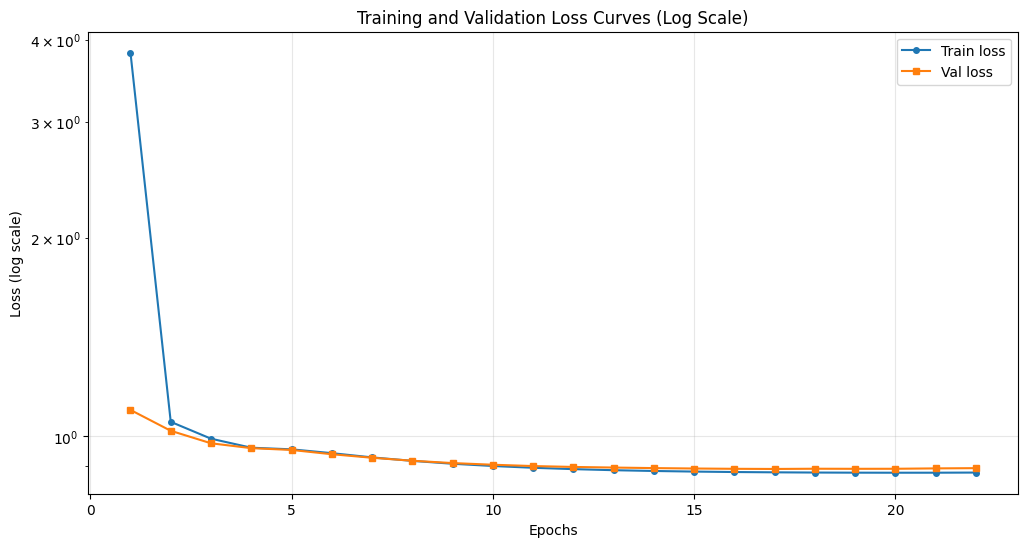

In [37]:
import matplotlib.pyplot as plt
epochs_count = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_count, train_losses, label='Train loss', marker='o', markersize=4)
plt.plot(epochs_count, val_losses, label='Val loss', marker='s', markersize=4)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.title('Training and Validation Loss Curves (Log Scale)')
plt.ylabel('Loss (log scale)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

tokenizer = AutoTokenizer.from_pretrained("models/Qwen/Qwen3-1.7B", trust_remote_code=True)

base_model = AutoModelForCausalLM.from_pretrained(
    "models/Qwen/Qwen3-1.7B",
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True
)

model = PeftModel.from_pretrained(base_model, "./zh_en_adapter_best")
model.eval()

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 2048)
        (layers): ModuleList(
          (0-27): 28 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_fea

In [15]:
input_text = "我每天要去 the city"
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=10,
    do_sample=True,
    temperature=0.5
)

print(tokenizer.decode(output[0]))

我每天要去 the city 什么的,然后呢,  It's
